In [1]:
import numpy as np
from pathlib import Path
import os, json, sys
import matplotlib.pyplot as plt
cwd = Path.cwd()
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

from groupBMC.groupBMC import GroupBMC

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Time constant

## Tau values across conditions

In [22]:
tau_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        tau_list = []
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            tau_list.append(params['tau'])
        tau_dict[f'{task}_{period}'] = tau_list

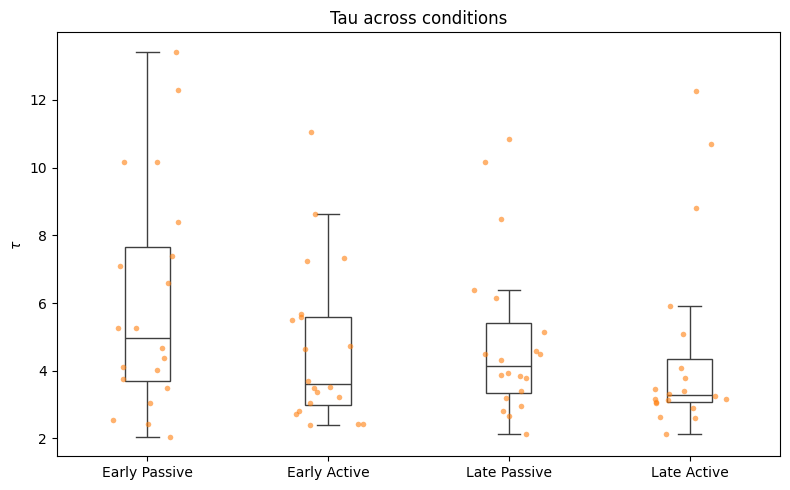

Mann–Whitney U tests:
Early Passive vs Early Active: U=247.0, p=0.2085
Late Passive vs Late Active: U=250.0, p=0.1806
Early Passive vs Late Passive: U=238.0, p=0.3104
Early Active vs Late Active: U=221.0, p=0.5792


In [23]:
# -----------------------------
# Reformat data
# -----------------------------
order = [
    'Passive_early',
    'Active_early',
    'Passive_late',
    'Active_late'
]

labels = [
    'Early Passive',
    'Early Active',
    'Late Passive',
    'Late Active'
]

data = []
for cond, label in zip(order, labels):
    for tau in tau_dict[cond]:
        data.append({'Condition': label, 'tau': tau})

df = pd.DataFrame(data)

# -----------------------------
# Rainplot
# -----------------------------
plt.figure(figsize=(8, 5))

# Boxplot (summary)
sns.boxplot(
    data=df,
    x='Condition',
    y='tau',
    order=labels,
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'none'},
    showfliers=False,
    whiskerprops={'linewidth': 1}
)

# Jittered points (rain)
sns.stripplot(
    data=df,
    x='Condition',
    y='tau',
    order=labels,
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.ylabel(r'$\tau$')
plt.xlabel('')
plt.title('Tau across conditions')
plt.tight_layout()
plt.show()

# -----------------------------
# Statistical comparisons
# -----------------------------
comparisons = [
    ('Early Passive', 'Early Active'),
    ('Late Passive', 'Late Active'),
    ('Early Passive', 'Late Passive'),
    ('Early Active', 'Late Active'),
]

print("Mann–Whitney U tests:")
for c1, c2 in comparisons:
    x = df[df['Condition'] == c1]['tau']
    y = df[df['Condition'] == c2]['tau']
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    print(f'{c1} vs {c2}: U={u:.1f}, p={p:.4g}')

## Correlation between early and late tau

Passive: Spearman ρ = 0.68, p = 0.0008773
Active: Spearman ρ = 0.73, p = 0.0002412


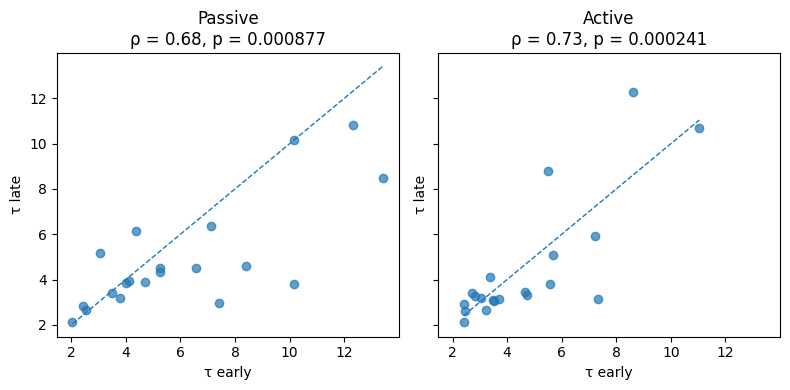

In [24]:
from scipy.stats import spearmanr

for task in ['Passive', 'Active']:
    early = tau_dict[f'{task}_early']
    late  = tau_dict[f'{task}_late']

    rho, p = spearmanr(early, late)

    print(f'{task}: Spearman ρ = {rho:.2f}, p = {p:.4g}')


import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

for ax, task in zip(axes, ['Passive', 'Active']):
    early = np.array(tau_dict[f'{task}_early'])
    late  = np.array(tau_dict[f'{task}_late'])

    rho, p = spearmanr(early, late)

    ax.scatter(early, late, alpha=0.7)
    ax.plot([early.min(), early.max()],
            [early.min(), early.max()],
            '--', linewidth=1)

    ax.set_title(f'{task}\nρ = {rho:.2f}, p = {p:.3g}')
    ax.set_xlabel('τ early')
    ax.set_ylabel('τ late')

plt.tight_layout()
plt.show()


# Measurement noise fitted accross conditions

In [9]:
sm_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        sm_list = []
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            sm_list.append(params['measure_noise'])
        sm_dict[f'{task}_{period}'] = sm_list

Passive: mean=0.610, std=0.123
Active: mean=0.527, std=0.131


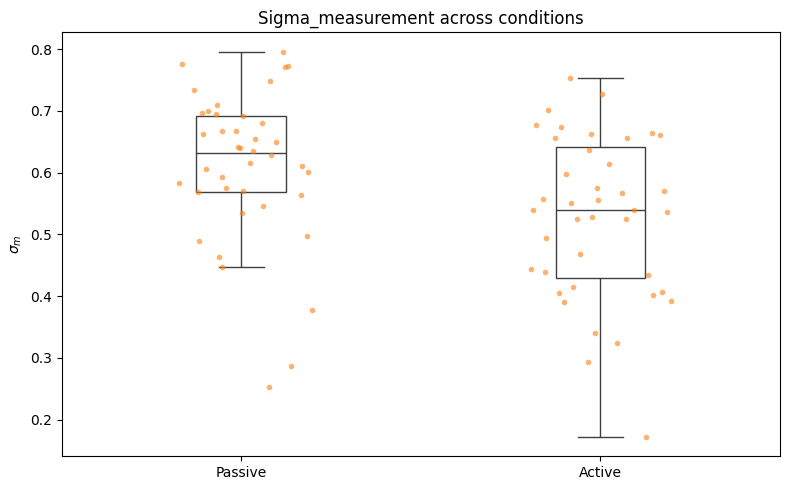

Paired Wilcoxon test (Passive vs Active):
W = 14.0, p = 0.0002098


In [12]:
# -----------------------------
# Reformat data: aggregate early+late -> Passive vs Active
# -----------------------------
data = []
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        for sm in sm_dict[f'{task}_{period}']:
            data.append({'Condition': task, 'sm': sm})

df = pd.DataFrame(data)

for label in ['Passive', 'Active']:
    print(f'{label}: mean={df[df["Condition"] == label]["sm"].mean():.3f}, std={df[df["Condition"] == label]["sm"].std():.3f}')

# -----------------------------
# Rainplot
# -----------------------------
plt.figure(figsize=(8, 5))

# Boxplot (summary)
sns.boxplot(
    data=df,
    x='Condition',
    y='sm',
    order=['Passive', 'Active'],
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'none'},
    showfliers=False,
    whiskerprops={'linewidth': 1}
)

# Jittered points (rain)
sns.stripplot(
    data=df,
    x='Condition',
    y='sm',
    order=['Passive', 'Active'],
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.ylabel(r'$\sigma_{m}$')
plt.xlabel('')
plt.title('Sigma_measurement across conditions')
plt.tight_layout()
plt.show()

# -----------------------------
# Statistical comparisons (Passive vs Active) - Paired Wilcoxon
# -----------------------------
from scipy.stats import wilcoxon

# Aggregate by participant to create paired data
participant_data = []
for part in range(20):
    passive_mean = np.mean([sm_dict['Passive_early'][part], sm_dict['Passive_late'][part]])
    active_mean = np.mean([sm_dict['Active_early'][part], sm_dict['Active_late'][part]])
    participant_data.append({
        'Participant': part,
        'Passive': passive_mean,
        'Active': active_mean
    })

paired_df = pd.DataFrame(participant_data)

# Paired Wilcoxon test
stat, p = wilcoxon(paired_df['Passive'], paired_df['Active'], alternative='two-sided')
print("Paired Wilcoxon test (Passive vs Active):")
print(f"W = {stat:.1f}, p = {p:.4g}")

# Process noise fitted accross conditions

In [14]:
sp_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        sp_list = []
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            sp_list.append(params['process_noise'])
        sp_dict[f'{task}_{period}'] = sp_list

Passive: mean=0.435, std=0.149
Active: mean=0.510, std=0.145


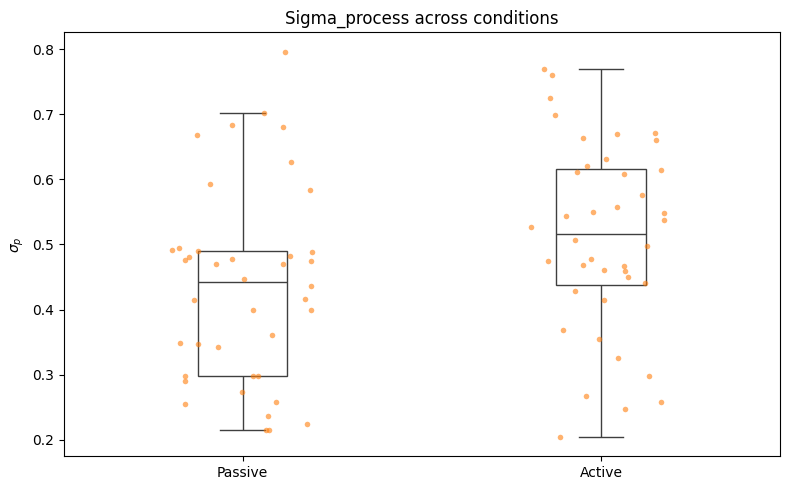

Paired Wilcoxon test (Passive vs Active):
W = 30.0, p = 0.003654


In [15]:
# -----------------------------
# Reformat data: aggregate early+late -> Passive vs Active
# -----------------------------
data = []
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        for sp in sp_dict[f'{task}_{period}']:
            data.append({'Condition': task, 'sp': sp})

df = pd.DataFrame(data)

for label in ['Passive', 'Active']:
    print(f'{label}: mean={df[df["Condition"] == label]["sp"].mean():.3f}, std={df[df["Condition"] == label]["sp"].std():.3f}')

# -----------------------------
# Rainplot
# -----------------------------
plt.figure(figsize=(8, 5))

# Boxplot (summary)
sns.boxplot(
    data=df,
    x='Condition',
    y='sp',
    order=['Passive', 'Active'],
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'none'},
    showfliers=False,
    whiskerprops={'linewidth': 1}
)

# Jittered points (rain)
sns.stripplot(
    data=df,
    x='Condition',
    y='sp',
    order=['Passive', 'Active'],
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.ylabel(r'$\sigma_{p}$')
plt.xlabel('')
plt.title('Sigma_process across conditions')
plt.tight_layout()
plt.show()

# -----------------------------
# Statistical comparisons (Passive vs Active) - Paired Wilcoxon
# -----------------------------
from scipy.stats import wilcoxon

# Aggregate by participant to create paired data
participant_data = []
for part in range(20):
    passive_mean = np.mean([sp_dict['Passive_early'][part], sp_dict['Passive_late'][part]])
    active_mean = np.mean([sp_dict['Active_early'][part], sp_dict['Active_late'][part]])
    participant_data.append({
        'Participant': part,
        'Passive': passive_mean,
        'Active': active_mean
    })

paired_df = pd.DataFrame(participant_data)

# Paired Wilcoxon test
stat, p = wilcoxon(paired_df['Passive'], paired_df['Active'], alternative='two-sided')
print("Paired Wilcoxon test (Passive vs Active):")
print(f"W = {stat:.1f}, p = {p:.4g}")

# Noise parameters ratio (sp / sm)

In [16]:
# Noise parameters ratio (sm / sp)
ratio_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        ratio_list = []
        for part in range(20):
            sp = sp_dict[f'{task}_{period}'][part]
            sm = sm_dict[f'{task}_{period}'][part]
            ratio_list.append(sm / sp)
        ratio_dict[f'{task}_{period}'] = ratio_list

Passive: mean=1.666, std=0.841
Active: mean=1.223, std=0.733


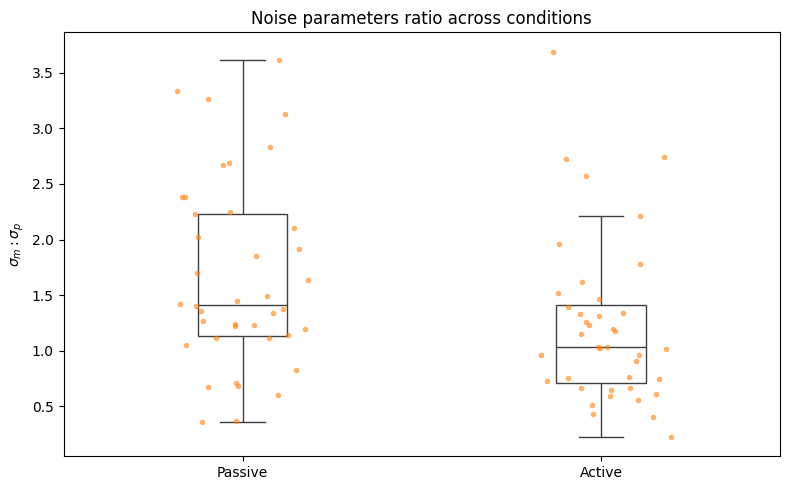

Paired Wilcoxon test (Passive vs Active):
W = 22.0, p = 0.001017


In [17]:
# -----------------------------
# Reformat data: aggregate early+late -> Passive vs Active
# -----------------------------
data = []
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        for ratio in ratio_dict[f'{task}_{period}']:
            data.append({'Condition': task, 'ratio': ratio})

df = pd.DataFrame(data)

for label in ['Passive', 'Active']:
    print(f'{label}: mean={df[df["Condition"] == label]["ratio"].mean():.3f}, std={df[df["Condition"] == label]["ratio"].std():.3f}')

# -----------------------------
# Rainplot
# -----------------------------
plt.figure(figsize=(8, 5))

# Boxplot (summary)
sns.boxplot(
    data=df,
    x='Condition',
    y='ratio',
    order=['Passive', 'Active'],
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'none'},
    showfliers=False,
    whiskerprops={'linewidth': 1}
)

# Jittered points (rain)
sns.stripplot(
    data=df,
    x='Condition',
    y='ratio',
    order=['Passive', 'Active'],
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.ylabel(r'$\sigma_{m} : \sigma_{p}$')
plt.xlabel('')
plt.title('Noise parameters ratio across conditions')
plt.tight_layout()
plt.show()

# -----------------------------
# Statistical comparisons (Passive vs Active) - Paired Wilcoxon
# -----------------------------
from scipy.stats import wilcoxon

# Aggregate by participant to create paired data
participant_data = []
for part in range(20):
    passive_mean = np.mean([ratio_dict['Passive_early'][part], ratio_dict['Passive_late'][part]])
    active_mean = np.mean([ratio_dict['Active_early'][part], ratio_dict['Active_late'][part]])
    participant_data.append({
        'Participant': part,
        'Passive': passive_mean,
        'Active': active_mean
    })

paired_df = pd.DataFrame(participant_data)

# Paired Wilcoxon test
stat, p = wilcoxon(paired_df['Passive'], paired_df['Active'], alternative='two-sided')
print("Paired Wilcoxon test (Passive vs Active):")
print(f"W = {stat:.1f}, p = {p:.4g}")

# SNR -> Gain relationship in the GainModulation model 

In [35]:
gains_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        gains_this_condition = {cat:[] for cat in range(7)}
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            for cat in range(7):
                if cat == 6 and (task == 'Active' or part < 10):
                    gains_this_condition[cat].append(np.nan)
                else:
                    gains_this_condition[cat].append(params[f'g{cat}'])
        gains_dict[f'{task}_{period}'] = gains_this_condition

In [37]:
def test_inverted_u(gains_per_cat, center_idx=[3, 4], extreme_idx=[0, 1, 2, 5]):
    
    center_vals = np.concatenate([gains_per_cat[i] for i in center_idx])
    extreme_vals = np.concatenate([gains_per_cat[i] for i in extreme_idx])
    
    # One-sided t-test: center > extremes
    tstat, p_two_sided = ttest_ind(center_vals, extreme_vals, equal_var=False)
    
    # Convert to one-sided
    if tstat > 0:
        p_one_sided = p_two_sided / 2
    else:
        p_one_sided = 1 - p_two_sided / 2
    
    return tstat, p_one_sided

early | report : inverted-U test
t = 2.188, one-sided p = 0.0158
----------------------------------------
early | no-report : inverted-U test
t = 0.537, one-sided p = 0.2964
----------------------------------------


/tmp/ipykernel_990226/2666531356.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))
/home/thardy/soundmodelenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


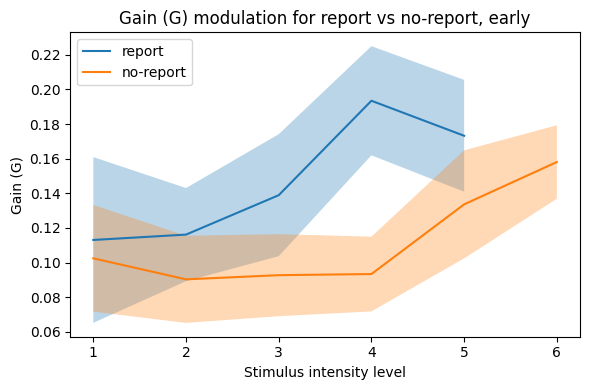

late | report : inverted-U test
t = 5.872, one-sided p = 0.0000
----------------------------------------
late | no-report : inverted-U test
t = 3.465, one-sided p = 0.0004
----------------------------------------


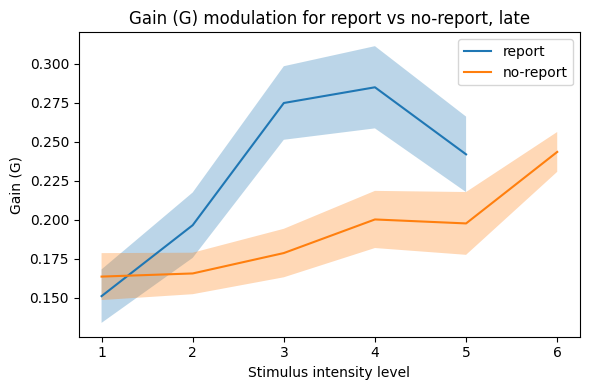

In [38]:
cats = range(7)

def mean_sem(x):
    x = np.array(x)
    return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))

for period in ['early', 'late']:
    plt.figure(figsize=(6, 4))
    
    for task, label in zip(['Active', 'Passive'], ['report', 'no-report']):
        means, sems = [], []
        gains_per_cat = []
    
        for cat in cats:
            vals = gains_dict[f'{task}_{period}'][cat]
            gains_per_cat.append(np.array(vals))
            m, s = mean_sem(vals)
            means.append(m)
            sems.append(s)
    
        means = np.array(means)
        sems  = np.array(sems)

        # Run inverted-U test
        tstat, pval = test_inverted_u(gains_per_cat)
        print(f"{period} | {label} : inverted-U test")
        print(f"t = {tstat:.3f}, one-sided p = {pval:.4f}")
        print("-"*40)

        if task=='Active':
            plt.plot(cats[1:-1], means[1:-1], label=label)
            plt.fill_between(cats[1:-1], means[1:-1] - sems[1:-1], means[1:-1] + sems[1:-1], alpha=0.3)
        else:
            plt.plot(cats[1:], means[1:], label=label)
            plt.fill_between(cats[1:], means[1:] - sems[1:], means[1:] + sems[1:], alpha=0.3)

        
    
    plt.xlabel('Stimulus intensity level')
    plt.ylabel('Gain (G)')
    plt.title(f'Gain (G) modulation for report vs no-report, {period}')
    plt.legend()
    plt.tight_layout()
    plt.show()


# SNR -> Input relationship in the GainModulation model 

In [45]:
iw_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        iw_this_condition = {cat:[] for cat in range(7)}
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainModulatedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            for cat in range(7):
                if cat == 6 and (task == 'Active' or part < 10):
                    iw_this_condition[cat].append(np.nan)
                else:
                    iw_this_condition[cat].append(params[f'w{cat}'])
        iw_dict[f'{task}_{period}'] = iw_this_condition

In [46]:
def test_inverted_u(gains_per_cat, center_idx=[3, 4], extreme_idx=[0, 1, 2, 5]):
    
    center_vals = np.concatenate([gains_per_cat[i] for i in center_idx])
    extreme_vals = np.concatenate([gains_per_cat[i] for i in extreme_idx])
    
    # One-sided t-test: center > extremes
    tstat, p_two_sided = ttest_ind(center_vals, extreme_vals, equal_var=False)
    
    # Convert to one-sided
    if tstat > 0:
        p_one_sided = p_two_sided / 2
    else:
        p_one_sided = 1 - p_two_sided / 2
    
    return tstat, p_one_sided

early | report : inverted-U test
t = 1.106, one-sided p = 0.1358
----------------------------------------
early | no-report : inverted-U test
t = -0.085, one-sided p = 0.5338
----------------------------------------


/tmp/ipykernel_990226/950537824.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))
/home/thardy/soundmodelenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


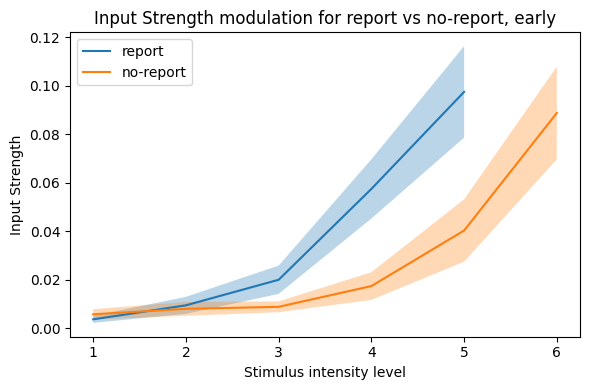

late | report : inverted-U test
t = 0.626, one-sided p = 0.2662
----------------------------------------
late | no-report : inverted-U test
t = 0.965, one-sided p = 0.1683
----------------------------------------


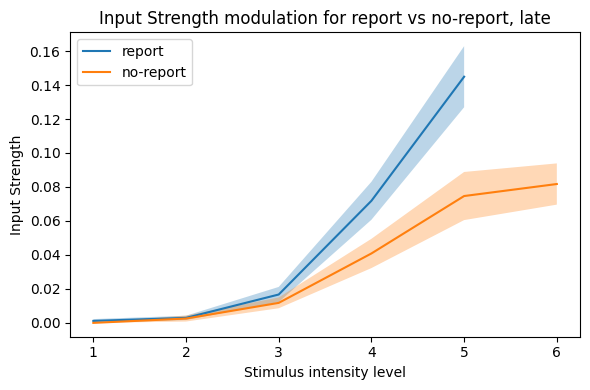

In [48]:
cats = range(7)

def mean_sem(x):
    x = np.array(x)
    return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))

for period in ['early', 'late']:
    plt.figure(figsize=(6, 4))
    
    for task, label in zip(['Active', 'Passive'], ['report', 'no-report']):
        means, sems = [], []
        iw_per_cat = []
    
        for cat in cats:
            vals = iw_dict[f'{task}_{period}'][cat]
            iw_per_cat.append(np.array(vals))
            m, s = mean_sem(vals)
            means.append(m)
            sems.append(s)
    
        means = np.array(means)
        sems  = np.array(sems)

        # Run inverted-U test
        tstat, pval = test_inverted_u(iw_per_cat)
        print(f"{period} | {label} : inverted-U test")
        print(f"t = {tstat:.3f}, one-sided p = {pval:.4f}")
        print("-"*40)

        if task=='Active':
            plt.plot(cats[1:-1], means[1:-1], label=label)
            plt.fill_between(cats[1:-1], means[1:-1] - sems[1:-1], means[1:-1] + sems[1:-1], alpha=0.3)
        else:
            plt.plot(cats[1:], means[1:], label=label)
            plt.fill_between(cats[1:], means[1:] - sems[1:], means[1:] + sems[1:], alpha=0.3)

        
    
    plt.xlabel('Stimulus intensity level')
    plt.ylabel('Input Strength')
    plt.title(f'Input Strength modulation for report vs no-report, {period}')
    plt.legend()
    plt.tight_layout()
    plt.show()


# SNR -> Input relationship in the GainFixed model 

In [51]:
iw_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        iw_this_condition = {cat:[] for cat in range(7)}
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainFixedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            for cat in range(7):
                if cat == 6 and (task == 'Active' or part < 10):
                    iw_this_condition[cat].append(np.nan)
                else:
                    iw_this_condition[cat].append(params[f'w{cat}'])
        iw_dict[f'{task}_{period}'] = iw_this_condition

In [52]:
def test_inverted_u(gains_per_cat, center_idx=[3, 4], extreme_idx=[0, 1, 2, 5]):
    
    center_vals = np.concatenate([gains_per_cat[i] for i in center_idx])
    extreme_vals = np.concatenate([gains_per_cat[i] for i in extreme_idx])
    
    # One-sided t-test: center > extremes
    tstat, p_two_sided = ttest_ind(center_vals, extreme_vals, equal_var=False)
    
    # Convert to one-sided
    if tstat > 0:
        p_one_sided = p_two_sided / 2
    else:
        p_one_sided = 1 - p_two_sided / 2
    
    return tstat, p_one_sided

early | report : inverted-U test
t = 1.733, one-sided p = 0.0432
----------------------------------------
early | no-report : inverted-U test
t = 0.282, one-sided p = 0.3892
----------------------------------------


/tmp/ipykernel_990226/615641088.py:5: RuntimeWarning: Mean of empty slice
  return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))


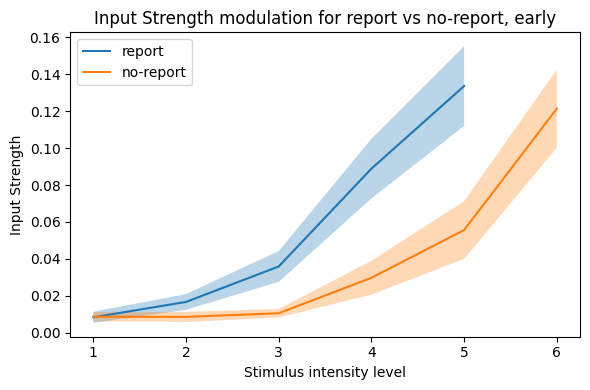

late | report : inverted-U test
t = 3.140, one-sided p = 0.0011
----------------------------------------
late | no-report : inverted-U test
t = 2.300, one-sided p = 0.0117
----------------------------------------


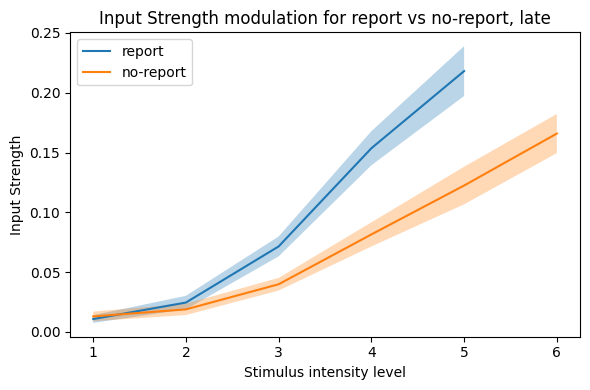

In [53]:
cats = range(7)

def mean_sem(x):
    x = np.array(x)
    return np.nanmean(x), np.nanstd(x) / np.sqrt(len(x))

for period in ['early', 'late']:
    plt.figure(figsize=(6, 4))
    
    for task, label in zip(['Active', 'Passive'], ['report', 'no-report']):
        means, sems = [], []
        iw_per_cat = []
    
        for cat in cats:
            vals = iw_dict[f'{task}_{period}'][cat]
            iw_per_cat.append(np.array(vals))
            m, s = mean_sem(vals)
            means.append(m)
            sems.append(s)
    
        means = np.array(means)
        sems  = np.array(sems)

        # Run inverted-U test
        tstat, pval = test_inverted_u(iw_per_cat)
        print(f"{period} | {label} : inverted-U test")
        print(f"t = {tstat:.3f}, one-sided p = {pval:.4f}")
        print("-"*40)

        if task=='Active':
            plt.plot(cats[1:-1], means[1:-1], label=label)
            plt.fill_between(cats[1:-1], means[1:-1] - sems[1:-1], means[1:-1] + sems[1:-1], alpha=0.3)
        else:
            plt.plot(cats[1:], means[1:], label=label)
            plt.fill_between(cats[1:], means[1:] - sems[1:], means[1:] + sems[1:], alpha=0.3)

        
    
    plt.xlabel('Stimulus intensity level')
    plt.ylabel('Input Strength')
    plt.title(f'Input Strength modulation for report vs no-report, {period}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Gain across conditions for the Gain Fixed Model

In [42]:
gain_dict = {}
for task in ['Passive', 'Active']:
    for period in ['early', 'late']:
        gain_list = []
        for part in range(20):
            file_path = f'Fit_{task}_{period}/GainFixedModel_part{part}_params'
            with open(file_path, "r") as f:
                params = json.load(f)
            gain_list.append(params['gain'])
        gain_dict[f'{task}_{period}'] = gain_list

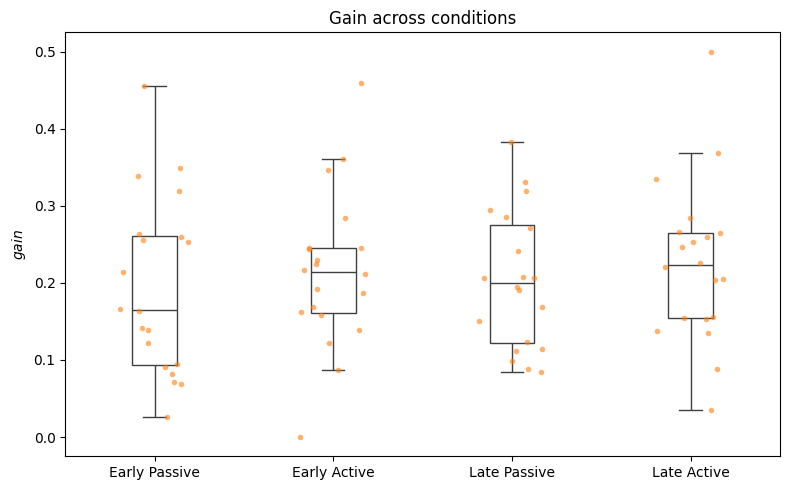

Mann–Whitney U tests:
Early Passive vs Early Active: U=175.0, p=0.5075
Late Passive vs Late Active: U=177.0, p=0.5428
Early Passive vs Late Passive: U=180.0, p=0.5979
Early Active vs Late Active: U=185.0, p=0.6949


In [44]:
# -----------------------------
# Reformat data
# -----------------------------
order = [
    'Passive_early',
    'Active_early',
    'Passive_late',
    'Active_late'
]

labels = [
    'Early Passive',
    'Early Active',
    'Late Passive',
    'Late Active'
]

data = []
for cond, label in zip(order, labels):
    for gain in gain_dict[cond]:
        data.append({'Condition': label, 'gain': gain})

df = pd.DataFrame(data)

# -----------------------------
# Rainplot
# -----------------------------
plt.figure(figsize=(8, 5))

# Boxplot (summary)
sns.boxplot(
    data=df,
    x='Condition',
    y='gain',
    order=labels,
    width=0.25,
    showcaps=True,
    boxprops={'facecolor': 'none'},
    showfliers=False,
    whiskerprops={'linewidth': 1}
)

# Jittered points (rain)
sns.stripplot(
    data=df,
    x='Condition',
    y='gain',
    order=labels,
    size=4,
    jitter=0.2,
    alpha=0.6
)

plt.ylabel(r'$gain$')
plt.xlabel('')
plt.title('Gain across conditions')
plt.tight_layout()
plt.show()

# -----------------------------
# Statistical comparisons
# -----------------------------
comparisons = [
    ('Early Passive', 'Early Active'),
    ('Late Passive', 'Late Active'),
    ('Early Passive', 'Late Passive'),
    ('Early Active', 'Late Active'),
]

print("Mann–Whitney U tests:")
for c1, c2 in comparisons:
    x = df[df['Condition'] == c1]['gain']
    y = df[df['Condition'] == c2]['gain']
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    print(f'{c1} vs {c2}: U={u:.1f}, p={p:.4g}')